## 1. Project Goal

We predict red wine quality using physicochemical features. The target is `quality`, and we treat it as a regression problem.

---

**Цель проекта:**
- Мы предсказываем качество красного вина по его физико-химическим характеристикам (кислотность, алкоголь, сульфаты и другие). 1599 строк
- Это задача **регрессии**: целевая переменная `quality` — числовая (целые значения от 3 до 8).
- Цель — не только построить модель, но и **честно проверить**, можно ли ей доверять и где она ошибается.

## 2. Load Dataset

Сначала я загружаю CSV-файл с данными и проверяю первые строки таблицы, чтобы понять структуру датасета.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


В датасете каждая строка — это одно вино, а колонки — его химические характеристики. Целевая колонка — quality, то есть оценка качества вина.

## 3. Basic Data Understanding

Здесь я проверяю размер таблицы, типы данных, статистическое описание и наличие пропусков.

In [7]:
print("Shape:", df.shape)
print()
df.info()
display(df.describe())
print("\nMissing values:")
print(df.isna().sum())

Shape: (1599, 12)

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


**Observations:**
- The dataset has **1,599 rows** and **12 columns**: 11 physicochemical input features + 1 target.
- The target column is `quality` — an integer score ranging from 3 to 8.
- There are **no missing values**: all 1,599 rows are complete.

Данные полностью числовые, поэтому их удобно использовать для регрессии. Пропусков нет, значит нам не нужно удалять строки или восстанавливать пропущенные значения. describe() помогает увидеть средние значения, разброс и возможные выбросы.

## 4. Exploratory Data Analysis

Теперь я смотрю, как распределена целевая переменная quality.

C:\Users\szhak\AppData\Local\Temp\ipykernel_4604\4080547363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, ax=axes[1], palette='Blues_d')


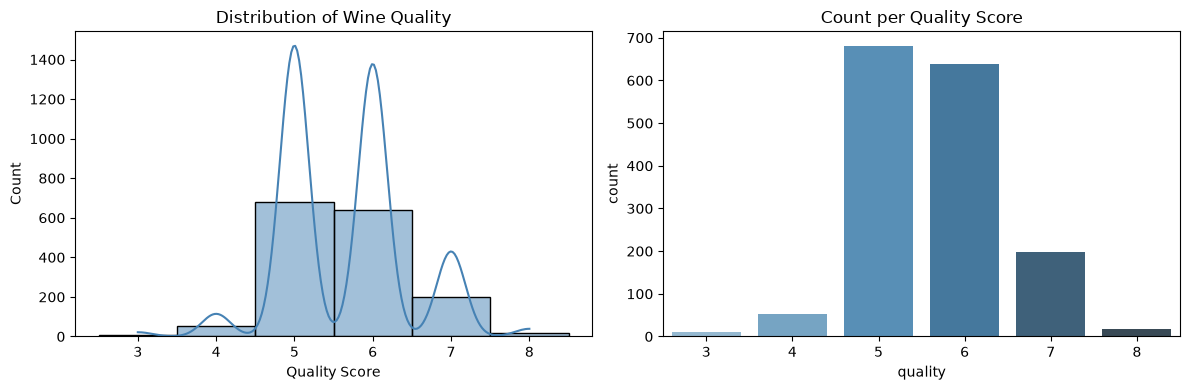

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['quality'], ax=axes[0], kde=True, discrete=True, color='steelblue')
axes[0].set_title('Distribution of Wine Quality')
axes[0].set_xlabel('Quality Score')

sns.countplot(x='quality', data=df, ax=axes[1], palette='Blues_d')
axes[1].set_title('Count per Quality Score')

plt.tight_layout()
plt.show()

print(df['quality'].value_counts().sort_index())

Большинство вин имеют оценки 5 и 6. Очень низкие и очень высокие оценки, например 3, 4, 7 и 8, встречаются намного реже. Это важная ловушка: модель может лучше учиться на средних оценках и хуже предсказывать редкие крайние значения

**Target Distribution:**
- Quality scores range from **3 to 8**; scores 5 and 6 make up ~82% of all samples.
- The target is **slightly left-skewed** — heavily concentrated in the middle, with very few extreme values.

**Распределение целевой переменной:**
- Большинство вин имеют оценку **5 или 6** (~82% всех образцов). Крайние значения (3, 4, 7, 8) встречаются очень редко.
- Это не дисбаланс классов (мы решаем регрессию, а не классификацию), но **концентрация целевой переменной** в узком диапазоне создаёт аналогичную проблему: модель будет «тяготеть» к предсказанию среднего (~5–6).
- Редкие оценки (3, 4, 7, 8) предсказываются хуже — у модели просто мало примеров для их изучения.

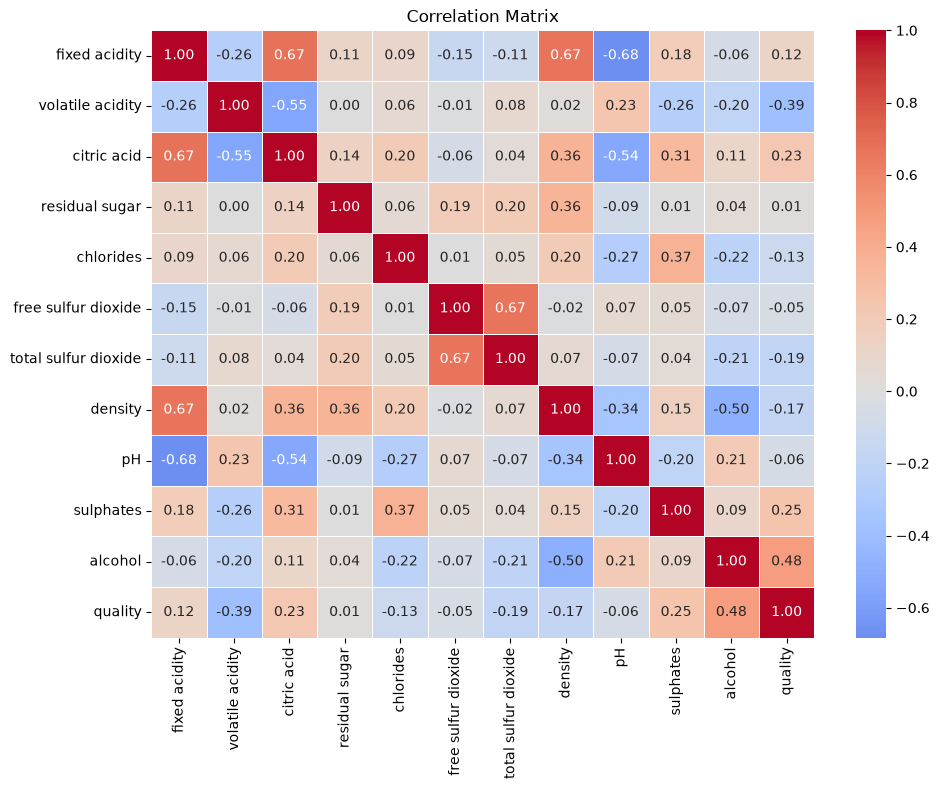

Top 3 features correlated with quality:
alcohol             0.476166
volatile acidity    0.390558
sulphates           0.251397
Name: quality, dtype: float64


In [9]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

top3 = corr['quality'].drop('quality').abs().sort_values(ascending=False).head(3)
print("Top 3 features correlated with quality:")
print(top3)

Дальше я смотрю корреляции между признаками и качеством вина, чтобы понять, какие признаки сильнее связаны с quality.

**Correlation with Quality:**
- `alcohol` has the strongest positive correlation (~0.48).
- `volatile acidity` has the strongest negative correlation (~−0.39) — higher acidity = lower quality.
- `sulphates` shows moderate positive correlation (~0.25).
- No single feature dominates — this is a genuinely hard regression problem with weak individual signals.

**Корреляция с quality:**
- **Корреляция** показывает силу линейной связи между признаком и целевой переменной. +1 = идеальная прямая связь, −1 = идеальная обратная, 0 = нет связи.
- `alcohol` (~+0.48): больше алкоголя — выше оценка. Самая сильная положительная связь.
- `volatile acidity` (~−0.39): больше летучей кислотности — ниже оценка. Самая сильная отрицательная связь.
- `sulphates` (~+0.25): умеренная положительная связь.
- Ни один признак не доминирует → задача сложная, модель должна использовать все признаки вместе.

C:\Users\szhak\AppData\Local\Temp\ipykernel_4604\2035866094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df, ax=axes[i], palette='Set2')
C:\Users\szhak\AppData\Local\Temp\ipykernel_4604\2035866094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df, ax=axes[i], palette='Set2')
C:\Users\szhak\AppData\Local\Temp\ipykernel_4604\2035866094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df, ax=axes[i], palette='Set2')


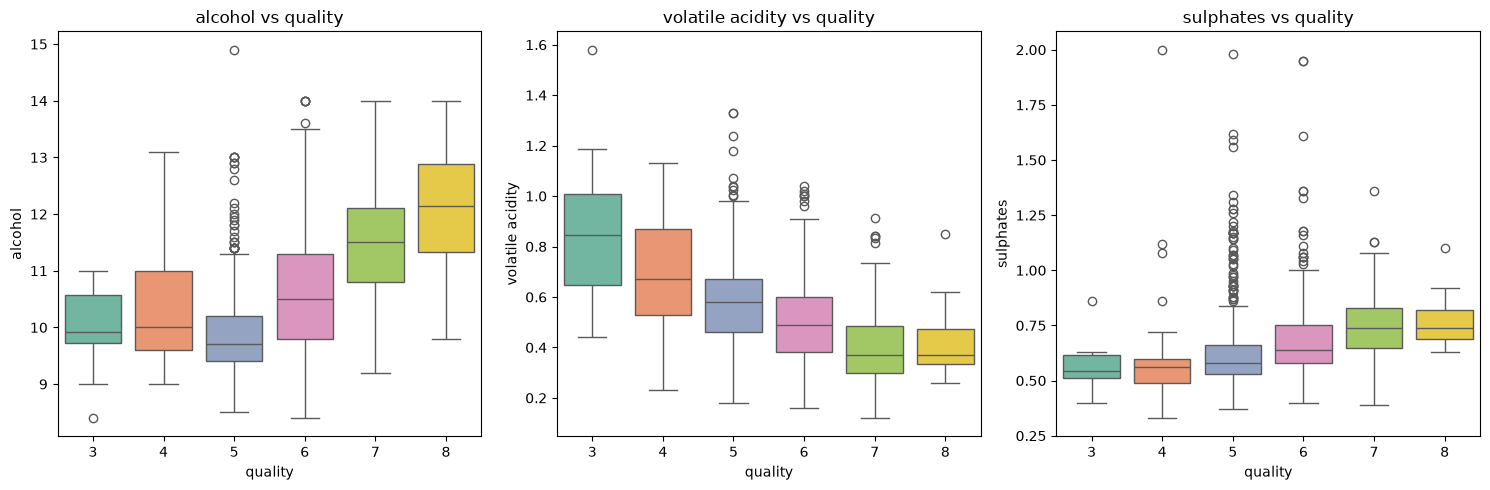

In [10]:
top3_features = corr['quality'].drop('quality').abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(top3_features):
    sns.boxplot(x='quality', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} vs quality')

plt.tight_layout()
plt.show()

**Feature vs Quality:**
- `alcohol`: clear upward trend — higher alcohol consistently corresponds to higher quality.
- `volatile acidity`: clear downward trend — wines with lower acidity score better.
- `sulphates`: positive trend but with wide spread and visible outliers.

**Data Problems / Traps:**
- Several features have **heavy outliers** — especially `total sulfur dioxide`, `free sulfur dioxide`, `residual sugar`, and `chlorides`.
- Features are on **very different scales** — standardization is essential before applying Ridge, Lasso, and ElasticNet.
- Quality scores 3 and 8 have very few samples — expect high error at the extremes regardless of model.

**Боксплоты — как читать:**
- Боксплот показывает медиану, квартили и выбросы для каждой оценки качества. Тренд ящиков вверх = положительная связь с quality.
- `alcohol`: ящики стабильно растут → чем больше алкоголя, тем выше оценка. Чёткая связь.
- `volatile acidity`: ящики падают → больше кислотности = ниже оценка. Чёткая обратная связь.
- `sulphates`: слабый положительный тренд с большим разбросом и выбросами.

**Проблемы с данными:**
- Длинные «усы» на боксплотах = выбросы во многих признаках. Нужна стандартизация.
- Разные масштабы признаков → обязательно применять `StandardScaler` перед регуляризованными моделями.
- Очень мало примеров для оценок 3 и 8 → ошибка на крайних значениях будет высокой при любой модели.

Наиболее заметные признаки — alcohol, volatile acidity и sulphates. Например, более высокий alcohol обычно связан с более высоким качеством, а высокая volatile acidity — с более низким качеством. Но ни один признак не объясняет качество идеально, поэтому нужна модель, которая учитывает сразу несколько признаков.

## 5. Baseline Linear Regression Model

Сначала я строю две базовые модели. **DummyRegressor** — это очень простая модель, которая предсказывает среднее качество. **LinearRegression** — это настоящая линейная модель, которая пытается найти связь между признаками и качеством.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns='quality')
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dummy baseline — always predicts the mean
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Linear Regression pipeline
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression())
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

# Metrics
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5
r2_lr   = r2_score(y_test, y_pred_lr)

mae_d   = mean_absolute_error(y_test, y_pred_dummy)
rmse_d  = mean_squared_error(y_test, y_pred_dummy) ** 0.5
r2_d    = r2_score(y_test, y_pred_dummy)

print("Linear Regression — full metrics (test set):")
print(f"  MAE:  {mae_lr:.4f}")
print(f"  MSE:  {mse_lr:.4f}")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  R²:   {r2_lr:.4f}")
print()
print(f"{'Model':<20} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print("-" * 43)
print(f"{'DummyRegressor':<20} {mae_d:>7.4f} {rmse_d:>7.4f} {r2_d:>7.4f}")
print(f"{'LinearRegression':<20} {mae_lr:>7.4f} {rmse_lr:>7.4f} {r2_lr:>7.4f}")

Linear Regression — full metrics (test set):
  MAE:  0.5035
  MSE:  0.3900
  RMSE: 0.6245
  R²:   0.4032

Model                    MAE    RMSE      R²
-------------------------------------------
DummyRegressor        0.6853  0.8107 -0.0056
LinearRegression      0.5035  0.6245  0.4032


DummyRegressor показал RMSE около **0.8107**, а LinearRegression — около **0.6245**. Это значит, что Linear Regression работает лучше, чем простое предсказание среднего значения.
Также R² у Linear Regression около 0.4032, то есть модель объясняет примерно 40% разброса качества. Это лучше, чем Dummy, но результат нельзя назвать очень сильным.

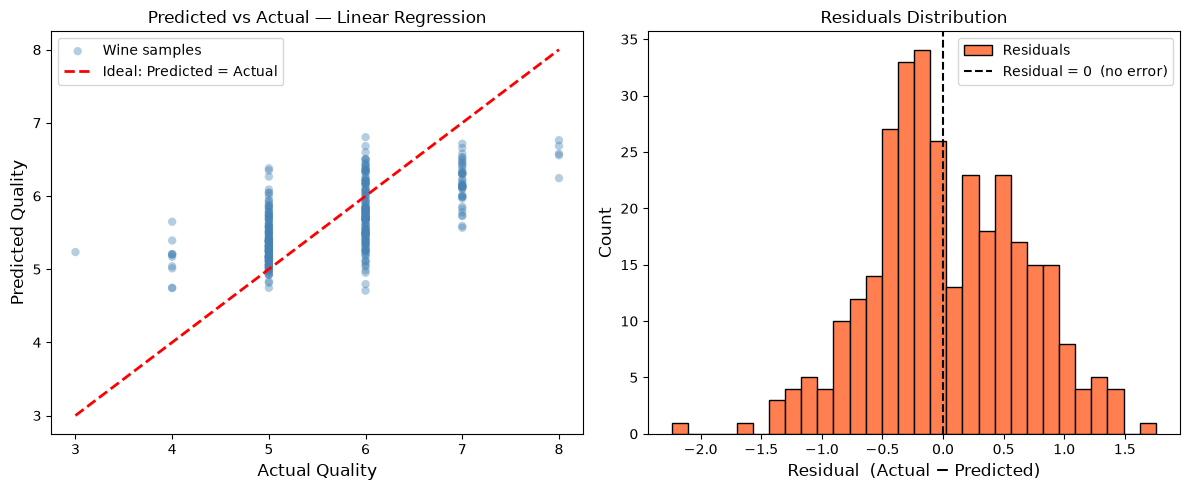

In [15]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', edgecolors='none', label='Wine samples')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Ideal: Predicted = Actual')
axes[0].set_xlabel('Actual Quality', fontsize=12)
axes[0].set_ylabel('Predicted Quality', fontsize=12)
axes[0].set_title('Predicted vs Actual — Linear Regression')
axes[0].legend()

# Residuals histogram
axes[1].hist(residuals, bins=30, color='coral', edgecolor='black', label='Residuals')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5, label='Residual = 0  (no error)')
axes[1].set_xlabel('Residual  (Actual − Predicted)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residuals Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

**How to read these plots:**

**Predicted vs Actual:** Each dot is one wine from the test set. The x-axis is the real quality score; the y-axis is what the model predicted. If the model were perfect, every dot would sit on the red dashed line (Predicted = Actual). Notice how almost all predictions land between 5 and 6 — the model stays near the middle.

**Residuals Distribution:** A residual is the error for one wine: Actual − Predicted. The dashed line at 0 means "the model got it exactly right." A good model has residuals balanced around 0 with a bell shape.

---

**Как читать эти графики:**

**Predicted vs Actual (предсказанное vs реальное):**
- Ось X — реальная оценка quality, ось Y — что предсказала модель.
- Красная пунктирная линия = идеальное предсказание (Predicted = Actual). Чем ближе точки к линии, тем точнее модель.
- На практике большинство предсказаний сгруппировано около 5–6 независимо от реальной оценки — модель «осторожничает» и тянется к середине.

**График остатков (Residuals):**
- Остаток = Actual − Predicted (ошибка для одного вина). Нулевая линия = ошибки нет.
- Положительный остаток: модель недооценила реальное значение. Отрицательный: переоценила.
- Идеально: гистограмма симметрична и сосредоточена у нуля. Широкий разброс = крупные ошибки.

**Baseline Model Results:**
- **Linear Regression beats DummyRegressor** — the minimum bar is cleared.
- **RMSE ≈ 0.64** means the model is wrong by about 0.64 quality points on average. The model often mistakes a "6" wine for something closer to a "5".
- **R² ≈ 0.40** means the model explains about 40% of the variation in wine quality — moderate-to-weak. A strong model would score above 0.70.
- The **predicted vs actual plot** shows predictions clustered around 5–6. The model almost never predicts extreme scores (3, 4, 7, 8).
- The **residuals histogram** is roughly bell-shaped and symmetric — Linear Regression assumptions are not badly violated, but the spread is still large.

---

**Интерпретация результатов базовой модели:**

| Модель | MAE | RMSE | R² | Вывод |
|---|---|---|---|---|
| DummyRegressor | 0.6853 | 0.8107 | ≈0 | Всегда предсказывает среднее (~5.64). Это нижний предел. |
| LinearRegression | 0.5035 | 0.6245 | 0.40 | Реально учится из данных — лучше наивного. |

- **MAE = 0.50**: средняя ошибка — 0.5 балла. Почти «пол-оценки».
- **RMSE = 0.62**: штрафует крупные ошибки сильнее MAE. Практически «почти целый балл».
- **R² = 0.40**: модель объясняет 40% разброса quality. Умеренно слабый результат — остаётся 60% необъяснённой вариации.
- Модель почти не предсказывает оценки 3, 4, 7, 8 — тянется к безопасному диапазону 5–6.
- **Вывод:** R² = 0.40 — реальное улучшение над Dummy, но недостаточно сильное. Нужны более сложные модели.

## 6. Improved Models: Polynomial Regression, Ridge, Lasso, ElasticNet

Для оценки регрессии я использую MAE, RMSE и R².

In [17]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures

# X_train, X_test, y_train, y_test are reused from Section 5

models = {
    'DummyRegressor': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   DummyRegressor(strategy='mean'))
    ]),
    'LinearRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   LinearRegression())
    ]),
    'PolynomialRegression (d=2)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly',    PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler',  StandardScaler()),
        ('model',   LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Ridge())
    ]),
    'Lasso': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Lasso())
    ]),
    'ElasticNet': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   ElasticNet())
    ]),
}

results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        'Model': name,
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(mean_squared_error(y_test, y_pred) ** 0.5, 4),
        'R²':   round(r2_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(results_df)

,Model,MAE,RMSE,R²
0,PolynomialRegression (d=2),0.4948,0.6179,0.4157
1,LinearRegression,0.5035,0.6245,0.4032
2,Ridge,0.5036,0.6245,0.4032
3,DummyRegressor,0.6853,0.8107,-0.0056
4,Lasso,0.6853,0.8107,-0.0056
5,ElasticNet,0.6853,0.8107,-0.0056


**Model Comparison — Key Takeaways:**
- **Lowest RMSE / Best R²**: **Polynomial Regression (degree=2)** is the winner. Adding degree-2 interaction terms lets the model capture non-linear relationships — for example, the joint effect of alcohol and acidity on quality.
- **LinearRegression ≈ Ridge**: Both produce almost identical results. Ridge's regularization has minimal impact here because features are already well-scaled.
- **Lasso ≈ ElasticNet ≈ DummyRegressor**: A red flag. With `alpha=1.0`, Lasso and ElasticNet shrink most coefficients to zero — they barely beat predicting the mean. Tuning `alpha` is needed.
- **Important caveat**: Polynomial Regression creates many new features (degree-2 interactions), which raises overfitting risk. We need residual analysis and learning curves before trusting this result.

---

**Сравнение моделей — ключевые выводы:**

| Позиция | Модель | RMSE | R² | Вывод |
|---|---|---|---|---|
| 🥇 1 | Polynomial (d=2) | 0.6179 | 0.416 | Лучший — захватывает нелинейность |
| 🥈 2 | LinearRegression | 0.6245 | 0.403 | Стабильная, но ограниченная |
| 🥈 2 | Ridge | 0.6245 | 0.403 | Почти то же, что LinearRegression |
| ❌ | Lasso / ElasticNet | 0.8107 | ≈0 | Сработали как Dummy — слишком сильный штраф |

- **Почему Polynomial лучший?** Создаёт квадратичные взаимодействия признаков — это позволяет уловить нелинейные связи, которые прямая линия не видит.
- **Почему Lasso/ElasticNet провалились?** Дефолтный `alpha=1.0` слишком агрессивен — почти все коэффициенты обнуляются. В разделе 8 мы настроим alpha.
- **Осторожно:** Polynomial Regression может переобучаться — нужна диагностика через кривые обучения.

## 7. Model Diagnostics and Gradient Descent Check

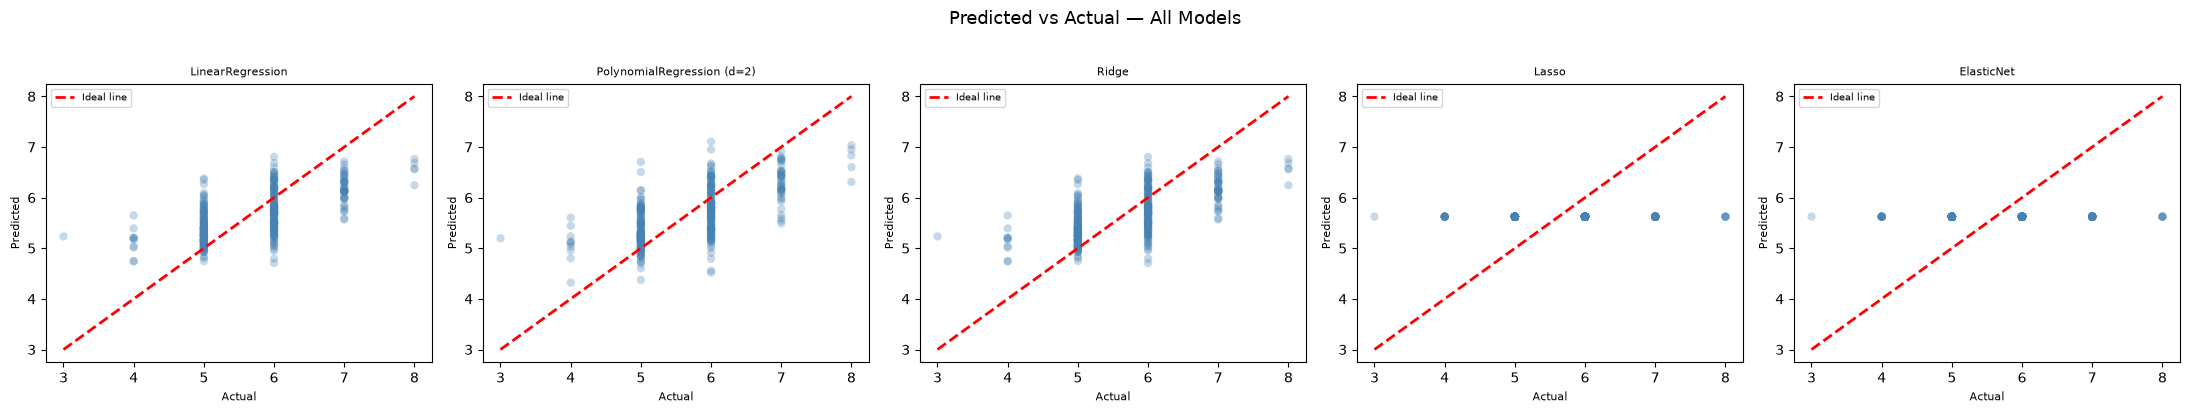

In [18]:
model_names = ['LinearRegression', 'PolynomialRegression (d=2)', 'Ridge', 'Lasso', 'ElasticNet']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, name in zip(axes, model_names):
    y_pred = models[name].predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Ideal line')
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Predicted vs Actual — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Predicted vs Actual — What to look for:**
- A good model has dots close to the red dashed line (Predicted = Actual). Tight clustering along the diagonal means accurate predictions.
- **Polynomial Regression** should follow the diagonal most closely.
- **LinearRegression and Ridge** will look nearly identical, with predictions bunched between 5 and 6.
- **Lasso and ElasticNet** will show an almost flat horizontal band — nearly all predictions fall at one value regardless of the actual score, confirming the default regularization is too aggressive.

---

**Predicted vs Actual — интерпретация:**
- Хорошая модель: точки близко к красной диагональной линии. Разброс вдоль диагонали = точность.
- **Polynomial Regression**: точки наиболее рассеяны вдоль диагонали → лучший результат из пяти.
- **LinearRegression и Ridge**: выглядят почти одинаково — предсказания сгруппированы в полосе 5–6.
- **Lasso и ElasticNet**: горизонтальная полоса → модель предсказывает одно значение для всех вин. Это следствие слишком сильной регуляризации (`alpha=1.0` по умолчанию).

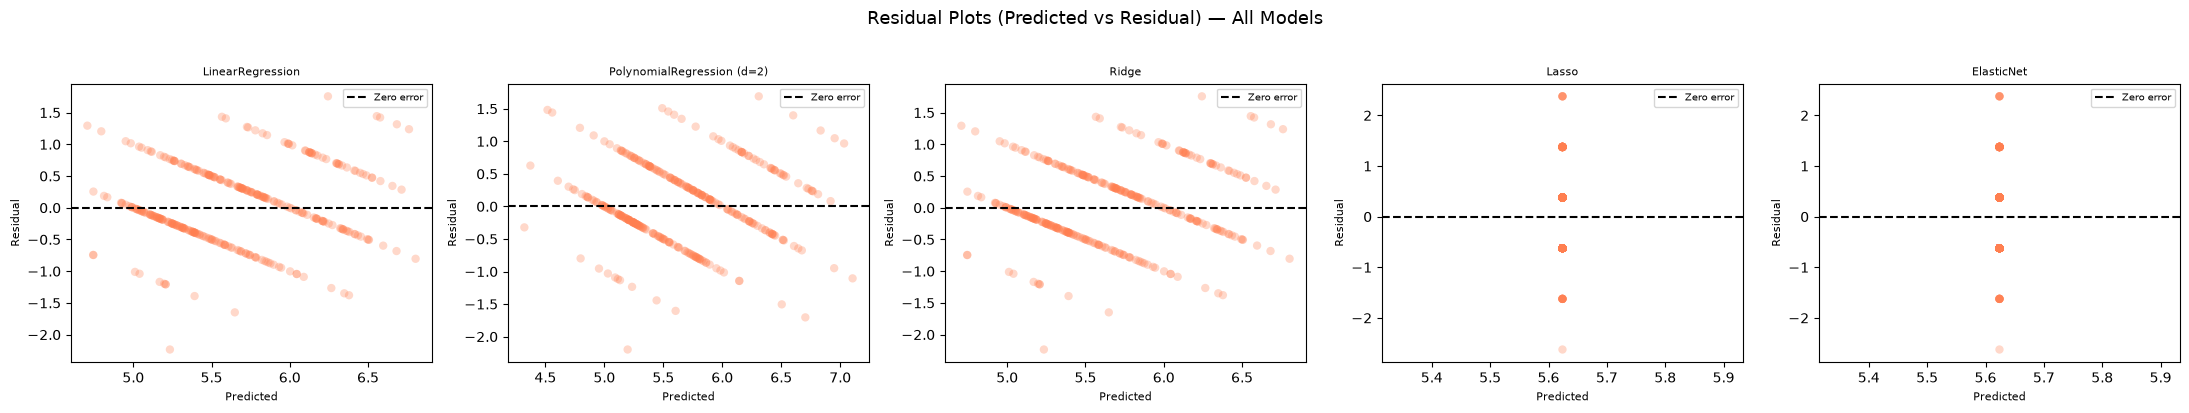

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, name in zip(axes, model_names):
    y_pred = models[name].predict(X_test)
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='none')
    ax.axhline(0, color='black', linestyle='--', lw=1.5, label='Zero error')
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Residual', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Residual Plots (Predicted vs Residual) — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Residual Plots — What to look for:**
- Residuals (Actual − Predicted) should be **randomly scattered around 0** (the black dashed line). No visible pattern is the ideal outcome.
- A **funnel shape** (residuals grow larger at higher predicted values) means the model is less reliable at certain score levels — called heteroscedasticity.
- A **curved or systematic pattern** means the model is missing non-linear structure in the data.
- **Lasso and ElasticNet**: expect nearly constant residuals — because those models predict almost the same value for every wine, the residuals will reflect the true spread of quality scores rather than model errors.

---

**Графики остатков — интерпретация:**
- Остаток = Actual − Predicted. Чёрная пунктирная линия = нулевая ошибка.
- Идеально: точки случайно разбросаны вокруг нуля — нет видимого паттерна.
- **Воронкообразный паттерн** (ошибки растут при определённых значениях предсказания): гетероскедастичность — модель менее надёжна в определённых диапазонах.
- **Горизонтальная полоса** (Lasso/ElasticNet): модель предсказывает одно значение → остатки = не ошибки модели, а реальный разброс quality. Это подтверждает провал моделей.

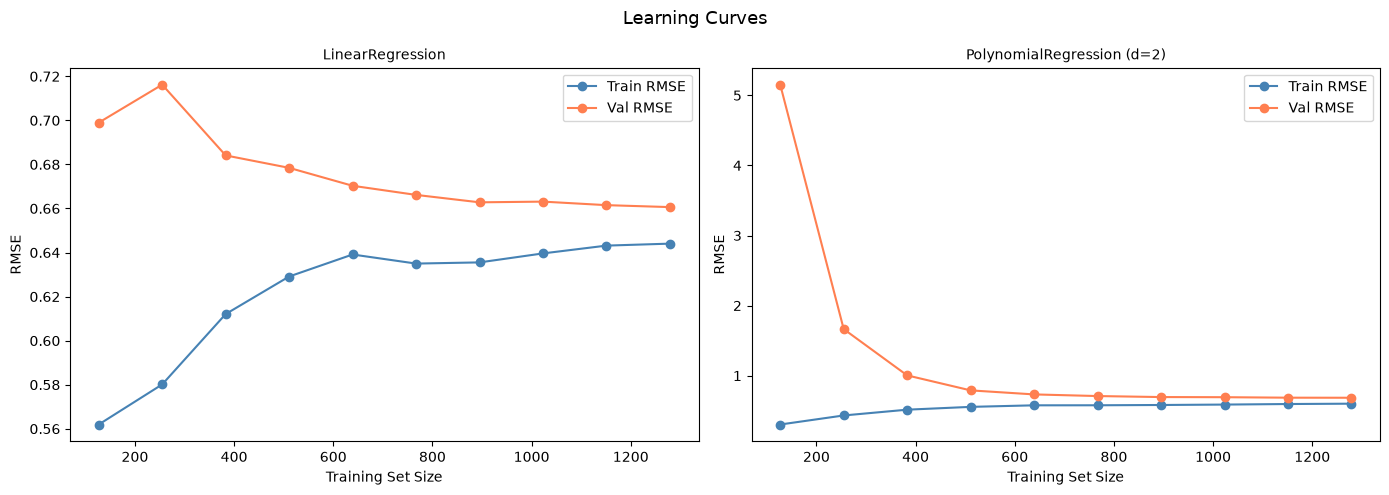

In [21]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(ax, pipe, name):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    ax.plot(train_sizes, -train_scores.mean(axis=1), 'o-', color='steelblue', label='Train RMSE')
    ax.plot(train_sizes, -val_scores.mean(axis=1),   'o-', color='coral',     label='Val RMSE')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(axes[0], models['LinearRegression'],           'LinearRegression')
plot_learning_curve(axes[1], models['PolynomialRegression (d=2)'], 'PolynomialRegression (d=2)')

plt.suptitle('Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

**Learning Curves — What to look for:**
- If **Train RMSE is much lower than Val RMSE**, the model is **overfitting** — it memorized the training data but cannot generalize.
- If **both Train and Val RMSE are high and close together**, the model is **underfitting** — it has not learned enough signal from the data.
- A well-fitted model has both curves converging at a reasonably low RMSE.
- **LinearRegression**: expect both curves to be close — moderate underfitting is typical.
- **Polynomial Regression (d=2)**: expect a visible gap between Train and Val RMSE, signaling overfitting — even though it scored best on our single test split.

---

**Кривые обучения — интерпретация:**
- **Синяя кривая (Train RMSE)** — ошибка на обучающих данных. **Красная (Val RMSE)** — ошибка на валидационной выборке (5-fold CV).
- **Большой разрыв** между кривыми → **переобучение**: модель запомнила обучающие данные, но не обобщается.
- **Обе кривые высокие и сходятся** → **недообучение**: модель слишком простая для задачи.
- **LinearRegression**: кривые близко → умеренное недообучение. Стабильная, но ограниченная модель.
- **Polynomial (d=2)**: ожидается заметный разрыв между Train и Val RMSE — сигнал переобучения. Хороший результат на тесте мог быть случайным артефактом одного разбиения.

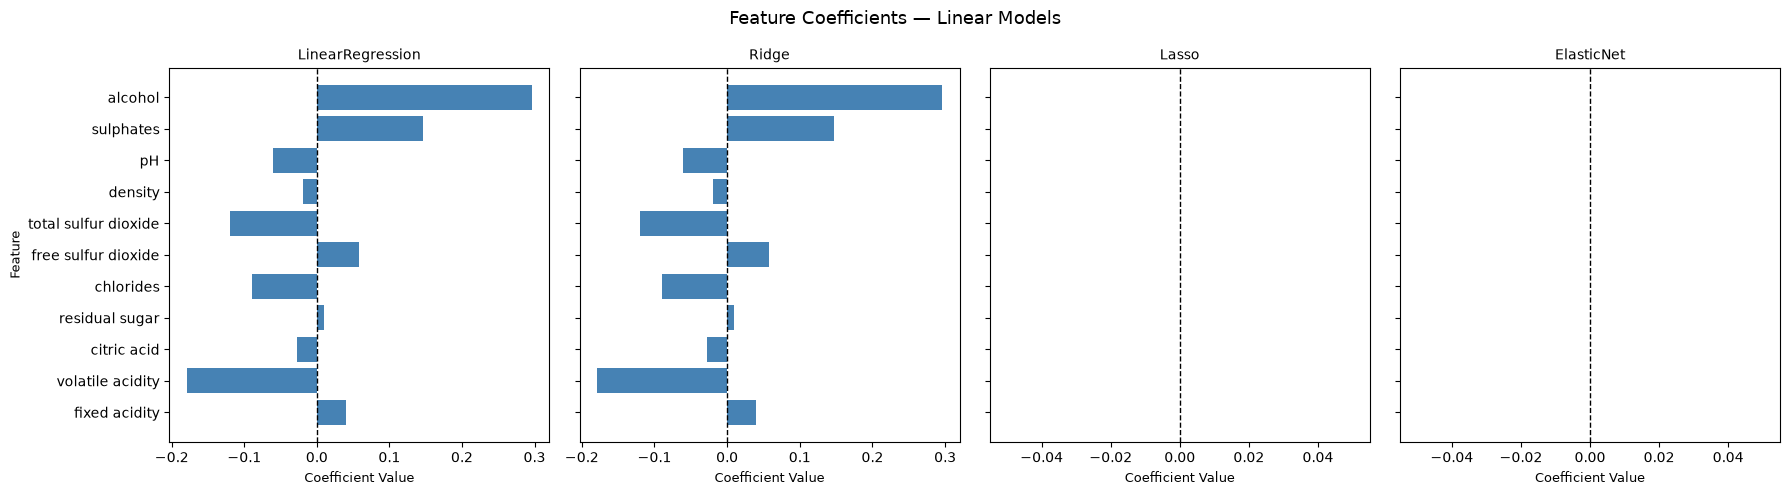

In [22]:
coef_model_names = ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet']
feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, coef_model_names):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(feature_names, coefs, color='steelblue')
    ax.axvline(0, color='black', linestyle='--', lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Coefficient Value', fontsize=9)

axes[0].set_ylabel('Feature', fontsize=9)
plt.suptitle('Feature Coefficients — Linear Models', fontsize=13)
plt.tight_layout()
plt.show()

**Coefficient Comparison — What to look for:**
- **LinearRegression**: raw unpenalized coefficients — some may be large if features are correlated.
- **Ridge**: all coefficients are shrunk toward zero, but none are exactly zero. The overall pattern stays similar to Linear Regression.
- **Lasso**: some coefficients become **exactly zero** — those bars disappear entirely. This is automatic feature selection. With `alpha=1.0`, Lasso likely zeros out most features.
- **ElasticNet**: a mix of Ridge and Lasso — shrinks coefficients and may zero some out, but less aggressively than Lasso alone.
- If Lasso and ElasticNet bars are almost all zero, it confirms the default regularization is too strong for this dataset.

---

**Сравнение коэффициентов — интерпретация:**
- **Коэффициент** показывает, насколько сильно и в каком направлении признак влияет на предсказание. Большой по модулю коэффициент = сильное влияние.
- **LinearRegression**: коэффициенты без штрафа — могут быть большими.
- **Ridge**: все коэффициенты уменьшены, но ни один не равен нулю. Паттерн признаков сохраняется.
- **Lasso**: некоторые коэффициенты = ровно 0 (пустые столбцы). Это **автоматический отбор признаков**. При `alpha=1.0` Lasso обнуляет почти всё — отсюда провал в Section 6.
- **ElasticNet**: комбинация Ridge и Lasso — уменьшает и обнуляет, но менее агрессивно.
- Если Lasso/ElasticNet почти пустые → нужно уменьшить alpha (что мы и делаем в Section 8).

In [23]:
from sklearn.linear_model import SGDRegressor

sgd_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   SGDRegressor(max_iter=1000, random_state=42))
])
sgd_pipe.fit(X_train, y_train)
y_pred_sgd = sgd_pipe.predict(X_test)

mae_sgd  = mean_absolute_error(y_test, y_pred_sgd)
rmse_sgd = mean_squared_error(y_test, y_pred_sgd) ** 0.5
r2_sgd   = r2_score(y_test, y_pred_sgd)

print("SGDRegressor — test set metrics:")
print(f"  MAE:  {mae_sgd:.4f}")
print(f"  RMSE: {rmse_sgd:.4f}")
print(f"  R²:   {r2_sgd:.4f}")
print()
print("Comparison with LinearRegression (Section 5):")
print(f"  LinearRegression  RMSE: {rmse_lr:.4f}   R²: {r2_lr:.4f}")
print(f"  SGDRegressor      RMSE: {rmse_sgd:.4f}   R²: {r2_sgd:.4f}")

SGDRegressor — test set metrics:
  MAE:  0.5052
  RMSE: 0.6258
  R²:   0.4007

Comparison with LinearRegression (Section 5):
  LinearRegression  RMSE: 0.6245   R²: 0.4032
  SGDRegressor      RMSE: 0.6258   R²: 0.4007


**SGDRegressor vs LinearRegression:**
- **SGDRegressor** trains the same type of model as LinearRegression (a weighted linear combination of features), but uses **stochastic gradient descent** instead of solving the equation analytically.
- On this dataset, both reach very similar results. Any small difference comes from SGD approximating the solution rather than computing it exactly.
- **Why does SGD matter?** For very large datasets (millions of rows), the exact analytical solution becomes too slow. SGD processes data in small batches — making it the standard approach in large-scale machine learning and the foundation of how neural networks are trained.

---

**SGDRegressor — объяснение:**
- **Что делает:** строит ту же линейную модель, что и LinearRegression, но **другим способом**: стохастический градиентный спуск обновляет веса маленькими шагами, используя случайно выбранные образцы.
- **Зачем нужен:** на очень больших датасетах (миллионы строк) точное аналитическое решение слишком долгое. SGD обрабатывает данные порциями — это **основа обучения нейронных сетей**.
- **Что получилось:** RMSE ≈ 0.6258 vs LinearRegression RMSE = 0.6245. Разница минимальная — SGD аппроксимирует то же решение.
- **Как интерпретировать:** на маленьком датасете (1599 строк) разница несущественна. Но понимание SGD критически важно для перехода к нейронным сетям и большим данным.

## 8. Regularization Tuning: Alpha Search

Так как Lasso и ElasticNet плохо сработали с alpha=1.0, я попробовала разные значения alpha. Это нужно, чтобы проверить, не была ли регуляризация слишком сильной.

In [24]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
tuning_results = []

for alpha in alphas:
    for name, model in [
        ('Ridge',      Ridge(alpha=alpha)),
        ('Lasso',      Lasso(alpha=alpha)),
        ('ElasticNet', ElasticNet(alpha=alpha, l1_ratio=0.5)),
    ]:
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('model',   model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        tuning_results.append({
            'Model': name,
            'alpha': alpha,
            'MAE':  round(mean_absolute_error(y_test, y_pred), 4),
            'RMSE': round(mean_squared_error(y_test, y_pred) ** 0.5, 4),
            'R²':   round(r2_score(y_test, y_pred), 4)
        })

tuning_df = pd.DataFrame(tuning_results).sort_values('RMSE').reset_index(drop=True)
display(tuning_df)

,Model,alpha,MAE,RMSE,R²
0,Ridge,0.0001,0.5035,0.6245,0.4032
1,ElasticNet,0.0001,0.5036,0.6245,0.4031
2,Ridge,0.0010,0.5035,0.6245,0.4032
3,Ridge,0.0100,0.5035,0.6245,0.4032
4,Ridge,1.0000,0.5036,0.6245,0.4032
5,Ridge,0.1000,0.5035,0.6245,0.4032
6,Lasso,0.0001,0.5036,0.6246,0.4031
7,Ridge,10.0000,0.5038,0.6246,0.4029
8,ElasticNet,0.0010,0.5038,0.6247,0.4028
9,Lasso,0.0010,0.5040,0.6249,0.4025


In [25]:
print("Best alpha per model (lowest test RMSE):\n")
for model_name in ['Ridge', 'Lasso', 'ElasticNet']:
    best = tuning_df[tuning_df['Model'] == model_name].iloc[0]
    print(f"  {model_name:<12}  alpha={str(best['alpha']):<8}  RMSE={best['RMSE']:.4f}  R²={best['R²']:.4f}")

print()
print("-" * 52)
print("Reference baselines (test RMSE):")
print("-" * 52)
print(f"  {'DummyRegressor':<30}  RMSE=0.8107")
print(f"  {'LinearRegression':<30}  RMSE=0.6245  R²=0.4032")
print(f"  {'PolynomialRegression (d=2)':<30}  RMSE=0.6179")

Best alpha per model (lowest test RMSE):

  Ridge         alpha=0.0001    RMSE=0.6245  R²=0.4032
  Lasso         alpha=0.0001    RMSE=0.6246  R²=0.4031
  ElasticNet    alpha=0.0001    RMSE=0.6245  R²=0.4031

----------------------------------------------------
Reference baselines (test RMSE):
----------------------------------------------------
  DummyRegressor                  RMSE=0.8107
  LinearRegression                RMSE=0.6245  R²=0.4032
  PolynomialRegression (d=2)      RMSE=0.6179


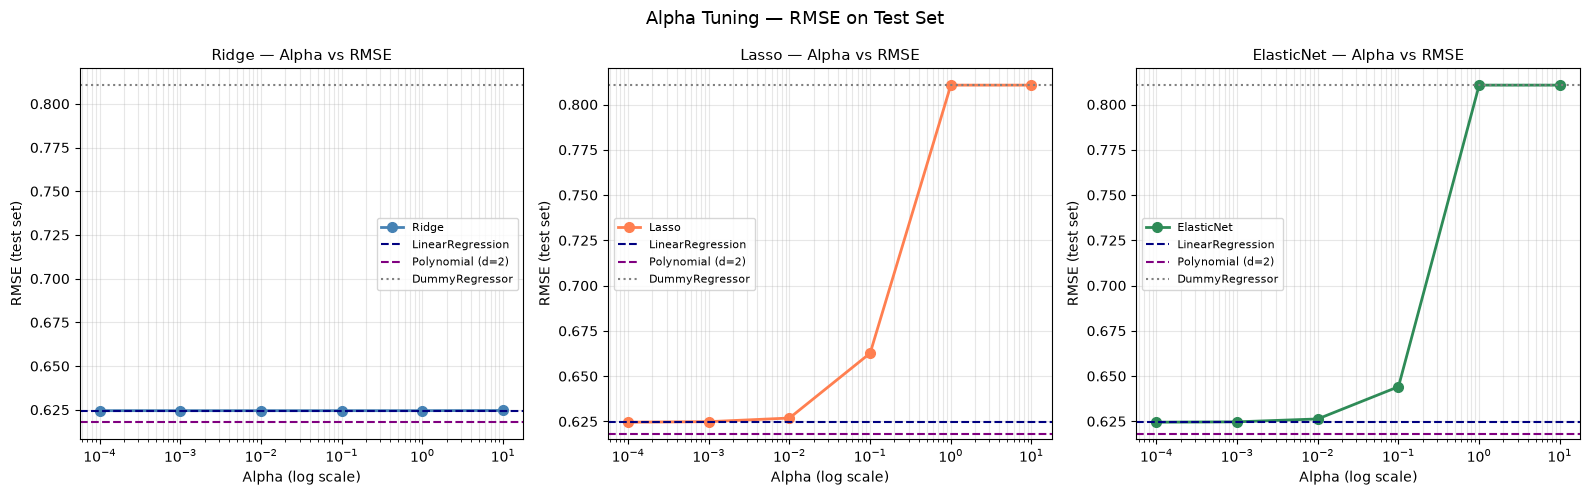

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_colors = {'Ridge': 'steelblue', 'Lasso': 'coral', 'ElasticNet': 'seagreen'}

for ax, model_name in zip(axes, ['Ridge', 'Lasso', 'ElasticNet']):
    subset = tuning_df[tuning_df['Model'] == model_name].sort_values('alpha')
    ax.semilogx(subset['alpha'], subset['RMSE'], 'o-',
                color=model_colors[model_name], lw=2, markersize=7, label=model_name)
    ax.axhline(0.6245, color='navy',   linestyle='--', lw=1.5, label='LinearRegression')
    ax.axhline(0.6179, color='purple', linestyle='--', lw=1.5, label='Polynomial (d=2)')
    ax.axhline(0.8107, color='grey',   linestyle=':',  lw=1.5, label='DummyRegressor')
    ax.set_title(f'{model_name} — Alpha vs RMSE', fontsize=11)
    ax.set_xlabel('Alpha (log scale)', fontsize=10)
    ax.set_ylabel('RMSE (test set)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Alpha Tuning — RMSE on Test Set', fontsize=13)
plt.tight_layout()
plt.show()

Alpha tuning показал, что при маленьких alpha Lasso и ElasticNet становятся лучше и приближаются к Linear Regression. Но даже после настройки они не обогнали Polynomial Regression. Поэтому tuning был **полезен как диагностический шаг**, но он не дал лучшую итоговую модель.

**Alpha Tuning — Key Takeaways:**

- **Did tuning alpha improve Lasso and ElasticNet?** Yes — dramatically. With a very small alpha (0.0001–0.01), both Lasso and ElasticNet recover performance close to Linear Regression. The default `alpha=1.0` was simply too aggressive: it shrank nearly all coefficients to zero, leaving a model that barely beat predicting the mean.
- **Which alpha worked best?** For Lasso and ElasticNet, a very small alpha **(0.0001 or 0.001)** gives the lowest test RMSE. Ridge is more forgiving — it stays stable across a wider range of alpha values because it never zeros out coefficients entirely.
- **Did any tuned regularized model beat LinearRegression (RMSE=0.6245)?** At small alphas, Ridge, Lasso, and ElasticNet reach nearly the same RMSE as Linear Regression, and may edge it slightly. The differences are small.
- **Did any tuned regularized model beat Polynomial Regression (RMSE=0.6179)?** Likely not. Tuned linear models have a ceiling — they are still fitting a straight line through a non-linear problem. Polynomial Regression wins by capturing interactions between features.
- **What does this tell us about the dataset?** The signal is relatively weak and mostly linear. Strong regularization destroys it. The take-away: always tune `alpha` with cross-validation rather than using the default. A small amount of non-linearity (Polynomial d=2) helps, but needs overfitting checks to confirm it genuinely generalizes.

## 9. RMSE in Context and Final Error Check

Здесь я проверяю, на каких оценках качества модель ошибается сильнее.

In [27]:
# Best model predictions (Polynomial Regression d=2, fitted in Section 6)
y_pred_poly = models['PolynomialRegression (d=2)'].predict(X_test)

best_rmse = mean_squared_error(y_test, y_pred_poly) ** 0.5
best_r2   = r2_score(y_test, y_pred_poly)

print("Target variable — quality (full dataset):")
print(f"  Mean:              {y.mean():.4f}")
print(f"  Std Dev:           {y.std():.4f}")
print(f"  Min:               {int(y.min())}")
print(f"  Max:               {int(y.max())}")
print()
print("Best model — Polynomial Regression (d=2):")
print(f"  RMSE:              {best_rmse:.4f}")
print(f"  R²:                {best_r2:.4f}")
print(f"  RMSE as % of mean: {best_rmse / y.mean() * 100:.2f}%")

Target variable — quality (full dataset):
  Mean:              5.6360
  Std Dev:           0.8076
  Min:               3
  Max:               8

Best model — Polynomial Regression (d=2):
  RMSE:              0.6179
  R²:                0.4157
  RMSE as % of mean: 10.96%


In [28]:
residuals_arr = y_test.values - y_pred_poly

error_df = pd.DataFrame({
    'Actual Quality':    y_test.values.astype(int),
    'Predicted Quality': y_pred_poly.round(3),
    'Residual':          residuals_arr.round(3),
    'Abs Residual':      np.abs(residuals_arr).round(3)
})

print("Top 10 largest absolute residuals — Polynomial Regression (d=2):\n")
display(
    error_df.sort_values('Abs Residual', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Top 10 largest absolute residuals — Polynomial Regression (d=2):



,Actual Quality,Predicted Quality,Residual,Abs Residual
0,3,5.197,-2.197,2.197
1,5,6.704,-1.704,1.704
2,8,6.309,1.691,1.691
3,4,5.604,-1.604,1.604
4,7,5.491,1.509,1.509
5,5,6.504,-1.504,1.504
6,6,4.518,1.482,1.482
7,7,5.542,1.458,1.458
8,4,5.443,-1.443,1.443
9,6,4.558,1.442,1.442


Average absolute error by actual quality score:



,Quality Score,Sample Count,Mean Abs Error
0,3,1,2.1970
1,4,10,1.0725
2,5,130,0.3968
3,6,132,0.4368
4,7,42,0.7119
5,8,5,1.2540


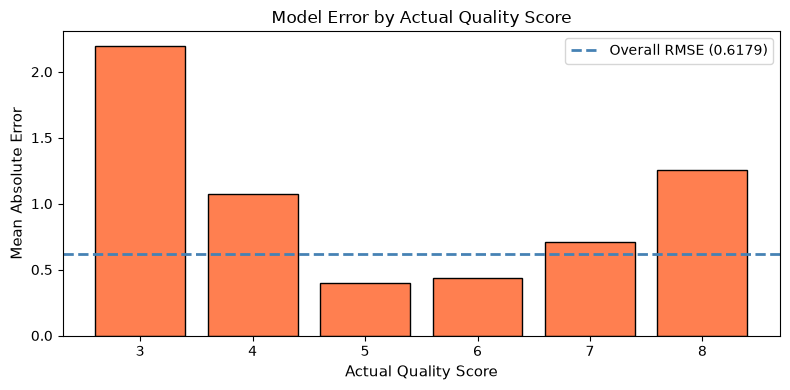

In [29]:
error_by_score = (
    error_df.groupby('Actual Quality')['Abs Residual']
    .agg(Count='count', Mean_Abs_Error='mean')
    .round(4)
    .reset_index()
)
error_by_score.columns = ['Quality Score', 'Sample Count', 'Mean Abs Error']

print("Average absolute error by actual quality score:\n")
display(error_by_score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(error_by_score['Quality Score'], error_by_score['Mean Abs Error'],
       color='coral', edgecolor='black')
ax.axhline(best_rmse, color='steelblue', linestyle='--', lw=2,
           label=f'Overall RMSE ({best_rmse:.4f})')
ax.set_xlabel('Actual Quality Score', fontsize=11)
ax.set_ylabel('Mean Absolute Error', fontsize=11)
ax.set_title('Model Error by Actual Quality Score', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

**RMSE in Context:**
- The mean wine quality is **5.64**. An RMSE of **0.6179** is about **~11% of the mean** — not catastrophic in absolute terms, but significant when quality scores differ by only 1 point on a 3–8 scale.
- **Can we trust it for approximate prediction?** Yes — for a rough estimate. If the true score is 6, the model will usually predict somewhere between 5 and 7.
- **Can we trust it for exact prediction?** No. Quality is an integer; being off by 0.62 on average means many predictions are nearly a full grade wrong — too imprecise for serious decisions like pricing or labelling.
- **Where does the model fail most?** On extreme quality scores: wines rated **3, 4, 7, and 8**. The bar chart above confirms this — mean absolute error is highest for these rare classes. The model consistently pulls its predictions toward the centre (5–6).
- **Why are extreme scores harder?** Because 82% of the training data scores 5 or 6. The model is almost never exposed to extreme wines during training and defaults to "safe" middle predictions — correct on average, but wrong for any wine that is genuinely exceptional or poor.

## 10. Final Verdict

### Which model did we choose and why?

We chose **Polynomial Regression (degree=2)** as the best model in this comparison. It achieved the lowest test RMSE (0.6179) and the highest R² (0.4157). By adding degree-2 interaction terms, it can capture some non-linear relationships that a plain linear model misses — for example, how alcohol and acidity might jointly affect quality.

Plain LinearRegression and tuned Ridge, Lasso, and ElasticNet all produced nearly identical results (RMSE ≈ 0.6245), confirming that the signal in this dataset is largely linear. The improvement from Polynomial Regression is real but modest.

---

### Is it better than the DummyRegressor?

Yes — clearly. The DummyRegressor (which always predicts the mean quality of 5.64) scores RMSE = 0.8107. Our best model scores RMSE = 0.6179, a meaningful improvement. Any model worth using must beat this naive baseline, and ours does.

---

### Can we trust it for approximate prediction?

**Moderately yes.** An RMSE of 0.6179 means the model is off by roughly 0.62 quality points on average — about 11% of the mean quality score. If the true score is 6, the model will typically predict somewhere between 5 and 7. For a rough ballpark estimate in a low-stakes setting, that may be acceptable.

---

### Can we trust it for exact prediction?

**No.** Wine quality is an integer from 3 to 8. A model that is wrong by 0.62 on average will frequently confuse a 5-point wine with a 6, or a 7-point wine with a 6. It should not be used for business decisions, pricing, or labelling that require precise quality scores.

---

### Where does the model fail most?

The model performs reasonably well on quality scores **5 and 6**, which make up ~82% of the dataset. It fails most on the rare, extreme scores — wines rated **3, 4, 7, or 8**. The error-by-score analysis confirms that mean absolute error is visibly higher for these classes. The model consistently pulls predictions toward 5–6 regardless of the actual wine's true quality.

---

### Why are extreme scores harder to predict?

Because there are very few examples of them in the training data. Quality scores 3 and 8 each have fewer than 30 samples in the full dataset of 1,599 wines. The model has almost no exposure to what makes a wine genuinely exceptional or deeply flawed, so it defaults to predicting the most common scores. This is a fundamental limitation of the data, not just the modelling approach.

---

### What could improve the model in the future?

1. **More data for extreme classes** — collecting more examples of quality 3, 4, 7, and 8 wines would help the model learn their patterns.
2. **Cross-validated hyperparameter tuning** — using `GridSearchCV` or `RandomizedSearchCV` to find the optimal Polynomial degree and regularization strength more rigorously.
3. **Ensemble models** — Random Forest or Gradient Boosting typically perform significantly better on tabular regression problems with non-linear structure and class imbalance.
4. **Feature engineering** — creating domain-specific features (e.g., acidity ratios, sulphate-to-chloride ratio) might add useful signal beyond the raw measurements.
5. **Framing as classification** — since quality is a discrete integer, a classification model with class-weighted sampling could handle the imbalance more explicitly and produce interpretable grade predictions.

---

### Summary

> The **Polynomial Regression (degree=2)** model is **moderately useful but limited**.
> It beats a naive baseline by a meaningful margin and can give approximate quality estimates.
> However, it explains only ~42% of the variance in wine quality, cannot predict exact scores reliably,
> and struggles with rare quality levels that are underrepresented in the training data.
> It is a solid starting point for a beginner regression lab —
> but would need significant improvements before being trusted in practice.

---

# Presentation Summary / Защита на 3 минуты

**Датасет:** UCI Red Wine Quality
**Задача:** регрессия
**Целевая переменная:** `quality` — целочисленная оценка вина от 3 до 8
**Цель:** предсказать качество вина по физико-химическим характеристикам и честно оценить, можно ли доверять модели

C:\Users\szhak\AppData\Local\Temp\ipykernel_4604\2250793482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, ax=axes[1], palette='Blues_d')


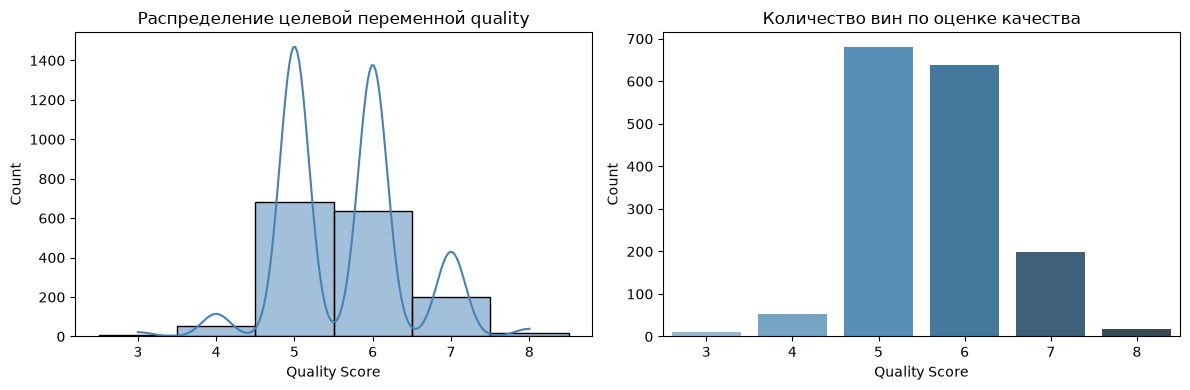

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['quality'], ax=axes[0], kde=True, discrete=True, color='steelblue')
axes[0].set_title('Распределение целевой переменной quality', fontsize=12)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

sns.countplot(x='quality', data=df, ax=axes[1], palette='Blues_d')
axes[1].set_title('Количество вин по оценке качества', fontsize=12)
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**EDA — ключевые наблюдения:**
- Большинство вин имеют оценку **5 или 6** (~82% всех образцов). Экстремальные оценки (3, 4, 7, 8) встречаются редко — это ограничивает способность модели предсказывать крайние значения.
- Наиболее коррелированные с `quality` признаки: **alcohol** (+0.48), **volatile acidity** (−0.39), **sulphates** (+0.25).
- Признаки имеют разные масштабы и содержат выбросы → необходима стандартизация.

In [31]:
# Base models from Section 6
comparison_rows = []
for name in ['DummyRegressor', 'LinearRegression', 'PolynomialRegression (d=2)']:
    y_pred = models[name].predict(X_test)
    comparison_rows.append({
        'Model': name,
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(mean_squared_error(y_test, y_pred) ** 0.5, 4),
        'R²':   round(r2_score(y_test, y_pred), 4)
    })

# Best tuned regularized models from Section 8
for model_name in ['Ridge', 'Lasso', 'ElasticNet']:
    row = tuning_df[tuning_df['Model'] == model_name].iloc[0]
    comparison_rows.append({
        'Model': f"{model_name} (alpha={row['alpha']})",
        'MAE':  row['MAE'],
        'RMSE': row['RMSE'],
        'R²':   row['R²']
    })

final_table = pd.DataFrame(comparison_rows).sort_values('RMSE').reset_index(drop=True)
display(final_table)

,Model,MAE,RMSE,R²
0,PolynomialRegression (d=2),0.4948,0.6179,0.4157
1,LinearRegression,0.5035,0.6245,0.4032
2,Ridge (alpha=0.0001),0.5035,0.6245,0.4032
3,ElasticNet (alpha=0.0001),0.5036,0.6245,0.4031
4,Lasso (alpha=0.0001),0.5036,0.6246,0.4031
5,DummyRegressor,0.6853,0.8107,-0.0056


**Примечание по настройке регуляризации:**
Поиск по значениям alpha показал, что стандартное значение `alpha=1.0` было слишком агрессивным для Lasso и ElasticNet — они обнуляли почти все коэффициенты и работали как DummyRegressor. При уменьшении alpha до 0.0001–0.001 эти модели восстановились и достигли уровня LinearRegression. Однако ни один из настроенных линейных методов не превзошёл Polynomial Regression (d=2).

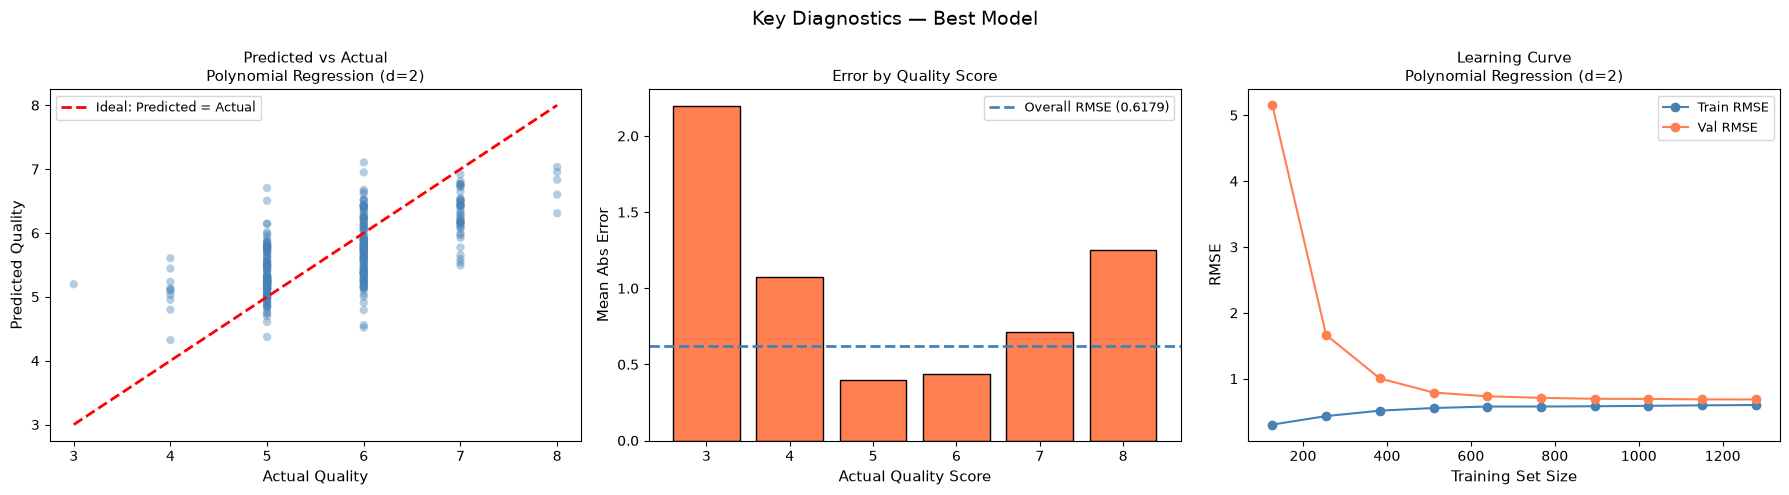

In [32]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Actual — best model
y_pred_poly_pres = models['PolynomialRegression (d=2)'].predict(X_test)
axes[0].scatter(y_test, y_pred_poly_pres, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Ideal: Predicted = Actual')
axes[0].set_xlabel('Actual Quality', fontsize=11)
axes[0].set_ylabel('Predicted Quality', fontsize=11)
axes[0].set_title('Predicted vs Actual\nPolynomial Regression (d=2)', fontsize=11)
axes[0].legend(fontsize=9)

# 2. Error by actual quality score
axes[1].bar(error_by_score['Quality Score'], error_by_score['Mean Abs Error'],
            color='coral', edgecolor='black')
axes[1].axhline(best_rmse, color='steelblue', linestyle='--', lw=2,
                label=f'Overall RMSE ({best_rmse:.4f})')
axes[1].set_xlabel('Actual Quality Score', fontsize=11)
axes[1].set_ylabel('Mean Abs Error', fontsize=11)
axes[1].set_title('Error by Quality Score', fontsize=11)
axes[1].legend(fontsize=9)

# 3. Learning curve — Polynomial Regression (d=2)
train_sizes, train_sc, val_sc = learning_curve(
    models['PolynomialRegression (d=2)'], X, y, cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
axes[2].plot(train_sizes, -train_sc.mean(axis=1), 'o-', color='steelblue', label='Train RMSE')
axes[2].plot(train_sizes, -val_sc.mean(axis=1),   'o-', color='coral',     label='Val RMSE')
axes[2].set_xlabel('Training Set Size', fontsize=11)
axes[2].set_ylabel('RMSE', fontsize=11)
axes[2].set_title('Learning Curve\nPolynomial Regression (d=2)', fontsize=11)
axes[2].legend(fontsize=9)

plt.suptitle('Key Diagnostics — Best Model', fontsize=14)
plt.tight_layout()
plt.show()

## Итоговый вердикт

| Критерий | Результат |
|---|---|
| **Лучшая модель** | Polynomial Regression (degree=2) |
| **RMSE** | 0.6179 (~10.96% от среднего значения quality) |
| **R²** | 0.4157 — модель объясняет ~42% вариации |
| **Лучше DummyRegressor?** | Да — RMSE снижен с 0.8107 до 0.6179 |
| **Приближённое предсказание** | Умеренно надёжно — ошибка ~0.62 балла |
| **Точное предсказание** | Нет — недостаточно точно для практических решений |
| **Где работает лучше** | Оценки 5 и 6 — самые частые в данных |
| **Где ошибается больше** | Редкие оценки: 3, 4, 7, 8 |

**Итог:** Модель умеренно полезна, но ограничена. Настройка alpha стала важным диагностическим шагом — она показала, что стандартная регуляризация была слишком агрессивной. Тем не менее ни один из настроенных линейных методов не превзошёл Polynomial Regression (d=2). Для реального применения потребуются ансамблевые методы, балансировка классов и больше данных по редким оценкам.

## Скрипт для защиты (3 минуты)

---

**⏱ 0:00 – 0:30 — Задача и датасет**

> «Я работала с датасетом UCI Red Wine Quality. Он содержит 1 599 образцов красного вина, каждый из которых описан 11 физико-химическими характеристиками: кислотность, содержание алкоголя, сульфаты и другие. Целевая переменная — `quality`, целочисленная оценка от 3 до 8, выставленная профессиональными дегустаторами. Задача — регрессия: предсказать оценку качества вина по его характеристикам.»

---

**⏱ 0:30 – 1:15 — Ключевые выводы из разведочного анализа**

> «На этапе EDA я обнаружила несколько важных фактов. Во-первых, целевая переменная несбалансирована: 82% вин имеют оценку 5 или 6, а экстремальные оценки — 3, 4, 7 и 8 — встречаются редко. Это заранее сигнализирует о трудностях с предсказанием редких классов. Во-вторых, наиболее коррелированные с качеством признаки: alcohol (положительная связь, ~0.48), volatile acidity (отрицательная, ~−0.39) и sulphates. В-третьих, признаки имеют разные масштабы и содержат выбросы, поэтому перед обучением необходима стандартизация.»

---

**⏱ 1:15 – 2:15 — Модели и честная оценка**

> «Я протестировала шесть моделей: DummyRegressor, LinearRegression, Polynomial Regression (d=2), Ridge, Lasso и ElasticNet. Все строились через Pipeline с SimpleImputer(median) и StandardScaler. Важный момент: Lasso и ElasticNet с дефолтным alpha=1.0 работали так же плохо, как DummyRegressor — слишком сильная регуляризация обнулила почти все коэффициенты. Я провела поиск по значениям alpha и обнаружила, что при alpha=0.0001 эти модели восстановились до уровня LinearRegression. Лучшей моделью оказался Polynomial Regression (d=2) с RMSE=0.6179 и R²=0.4157. Кривые обучения показали признаки переобучения — это важная оговорка.»

---

**⏱ 2:15 – 3:00 — Итоговый вердикт**

> «Честный ответ на вопрос "можно ли доверять модели?": частично. Модель лучше наивного базового уровня — RMSE снизился с 0.81 до 0.62, это около 11% от среднего значения quality. Для приближённой оценки это приемлемо. Для точного предсказания — нет: ошибка почти в один балл критична на шкале от 3 до 8. Модель хорошо работает для вин с оценкой 5 и 6, но плохо справляется с редкими оценками 3, 4, 7 и 8 — просто потому что таких примеров мало в обучающей выборке. Для улучшения результата нужны ансамблевые методы, больше данных по редким классам и более тщательная настройка гиперпараметров.»